# HW1. Самойлов Никита Русланович

### Смотри гитхаб:

https://github.com/NIKITA420240/Vega

## Task1

### Подзадача 1. Рассчитать вероятность того, что случайный ключ совпадет с одним из уже известных $10^8$ ключей в Bitcoin network

Bitcoin юзает уравнение $y^2 = x^3 + 7$ по модулю $p = 2^{256} - 2^{32} - 977$, порядок группы $n ~ 2^{256},$ тогда:

$$P(new_{key} \in set key) = \dfrac{10^8}{2^{256}} = \dfrac{10^8}{1024^{25} * 2^6} ~ \dfrac{10^8}{10^{75}} = \dfrac{1}{10^{67}}$$

### Подзадача 2.
Для каждого b = 20, 24, ... , 40

Найти простое p, чтобы n был b бит, то есть $2^{b - 1} \leq n < 2^b$ и проверить что n - простое

In [1]:
# y^2 = x^3 + 7, n - порядок группы, F_p - модуль по которому рассматриваем группу - простое
# Опишем классы для удобства
class Point_Bitcoin:
    def __init__(self, x: int, y: int):
        self.x = x
        self.y = y

    def is_valid(self, p: int) -> bool:
        if (self.x is None) or (self.y is None):
            return False
        if (self.x < 0) or (self.x >= p) or (self.y < 0) or (self.y >= p):
            return False
        return (self.y ** 2) % p == (self.x ** 3 + 7) % p

class Bitcoin:
    def __init__(self, b: int, n: int | None = None, p: int | None = None, seed: int = 42):
        self.b = b
        self.n = n
        self.p = p
        self.seed = seed
        self.rng = random.Random(seed)
    
    @staticmethod
    def is_prime(n: int) -> bool:
        if n <= 1:
            return False
        for i in range(2, int(n**0.5) + 1):
            if n % i == 0:
                return False
        return True

    def is_valid(self) -> bool:
        if not self.is_prime(self.p) and not self.is_prime(self.n):
            return False
        if self.find_n(self.p) != self.n:
            return False
        return True

    def find_n(self, p: int) -> int:
        if self.n is not None:
            return self.n
        n = 0

        for x in range(p):
            for y in range(p):
                point = Point_Bitcoin(x, y)
                if point.is_valid(p):
                    n += 1
        n = n + 1 # Add the point at infinity
        return n

    def find_p(self) -> int:
        if self.p is not None:
            return self.p
        
        for candidate in range(2**(self.b - 1), 2**self.b):
            if self.is_prime(candidate):
                n = self.find_n(candidate)
                if self.is_prime(n) and 2**(self.b - 1) <= n < 2**self.b:
                    self.p = candidate
                    self.n = n
                    return candidate
        return -1


In [2]:
import random
# Будем складывать объекты классов нужные нам
b = [i for i in range(2, 16, 4)]
bitcoin_models = [Bitcoin(bi) for bi in b]
for bitcoin_model in bitcoin_models:
    p = bitcoin_model.find_p()
    if p == -1:
        print(f"b: {bitcoin_model.b}, p: not found, n: not found")
    else:
        print(f"b: {bitcoin_model.b}, p: {bitcoin_model.p}, n: {bitcoin_model.n}")

b: 2, p: 2, n: 3
b: 6, p: 61, n: 61
b: 10, p: 547, n: 547
b: 14, p: 8209, n: 8293


### Быстрый поиск параметров уменьшенных кривых

Класс `ScaledSecp256k1` использует специальную структуру кривой $y^2=x^3+7$ с $j=0$. Поэтому он не перебирает $p^2$ пар $(x,y)$. Для простых $p\equiv1\pmod 3$ возможные следы Фробениуса получаются из представления $4p=L^2+27M^2$; правильный кандидат порядка дополнительно проверяется условием $nG=\mathcal O$.

In [3]:
from scaled_secp256k1 import CollisionResult, ScaledSecp256k1

bit_lengths = range(20, 41, 4)
bitcoin_models = []

for b in bit_lengths:
    model = ScaledSecp256k1(b=b, seed=42)
    p, n = model.find_parameters()
    bitcoin_models.append(model)
    print(f"b={b:2d}: p={p}, n={n}, bits(n)={n.bit_length()}")

b=20: p=528433, n=529117, bits(n)=20
b=24: p=8390323, n=8394151, bits(n)=24
b=28: p=134218291, n=134227243, bits(n)=28
b=32: p=2147496859, n=2147558143, bits(n)=32
b=36: p=34359740263, n=34359753217, bits(n)=36
b=40: p=549755835193, n=549757315399, bits(n)=40


### Пример эксперимента со столкновениями

В результате сохраняются как экспериментальная вероятность $C/M$, так и теоретическая вероятность $N/(n-1)$. Для больших $b$ потребуется увеличить число испытаний, иначе можно получить ноль столкновений.

In [4]:
result = bitcoin_models[0].collision_experiment(
    population_size=100_000,
    trials=100_000,
)

print(f"b={result.b}, collisions={result.collisions}/{result.trials}")
print(f"P experimental = {result.experimental_probability:.8f}")
print(f"P theoretical  = {result.theoretical_probability:.8f}")
print(f"log2(P experimental) = {result.log2_experimental_probability:.4f}")
print(f"log2(P theoretical)  = {result.log2_theoretical_probability:.4f}")

b=20, collisions=18688/100000
P experimental = 0.18688000
P theoretical  = 0.18899447
log2(P experimental) = -2.4198
log2(P theoretical)  = -2.4036


### Эксперимент для всех значений $b$

Для сравнимости используем одно и то же $N_{exp}=500\,000$ для всех уменьшенных кривых. Взять $N=10^8$ здесь нельзя: при $b=20$ и $b=24$ порядок группы меньше $10^8$, что нарушает условие $N<n$. Значение $N_{Bitcoin}=10^8$ будет использовано отдельно при экстраполяции к настоящей secp256k1.

Для каждого найденного точного порядка $n_b$ теоретическая вероятность вычисляется без аппроксимации: $P_{theory}=N_{exp}/(n_b-1)$. Число испытаний выбирается адаптивно так, чтобы ожидалось примерно 50 столкновений и экспериментальная вероятность не оказалась нулевой.

In [5]:
import math

N_exp = 500_000
target_collisions = 50
minimum_trials = 100_000
collision_results = []

for model in bitcoin_models:
    p_theory = N_exp / (model.n - 1)
    trials = max(minimum_trials, math.ceil(target_collisions / p_theory))
    result = model.collision_experiment(
        population_size=N_exp,
        trials=trials,
    )
    collision_results.append(result)
    print(
        f"b={result.b:2d}, trials={result.trials:>9,d}, "
        f"collisions={result.collisions:>5,d}, "
        f"P_exp={result.experimental_probability:.8e}, "
        f"P_theory={result.theoretical_probability:.8e}"
    )

b=20, trials=  100,000, collisions=94,635, P_exp=9.46350000e-01, P_theory=9.44972369e-01
b=24, trials=  100,000, collisions=6,058, P_exp=6.05800000e-02, P_theory=5.95652925e-02
b=28, trials=  100,000, collisions=  383, P_exp=3.83000000e-03, P_theory=3.72502625e-03
b=32, trials=  214,756, collisions=   59, P_exp=2.74730392e-04, P_theory=2.32822567e-04
b=36, trials=3,435,976, collisions=   54, P_exp=1.57160586e-05, P_theory=1.45519089e-05
b=40, trials=54,975,732, collisions=   45, P_exp=8.18542989e-07, P_theory=9.09492218e-07


### График $\log_2 P$ и экстраполяция

Синие точки — эксперимент, красные — точная формула $N_{exp}/(n_b-1)$. Штриховая линия продолжает зависимость до 256 бит для того же экспериментального $N_{exp}$. Звезда показывает отдельную оценку для настоящего Bitcoin, где используется заданное в условии $N_{Bitcoin}=10^8$ и точный порядок secp256k1.

In [6]:
!pip install matplotlib.pyplot

ERROR: Could not find a version that satisfies the requirement matplotlib.pyplot (from versions: none)
ERROR: No matching distribution found for matplotlib.pyplot


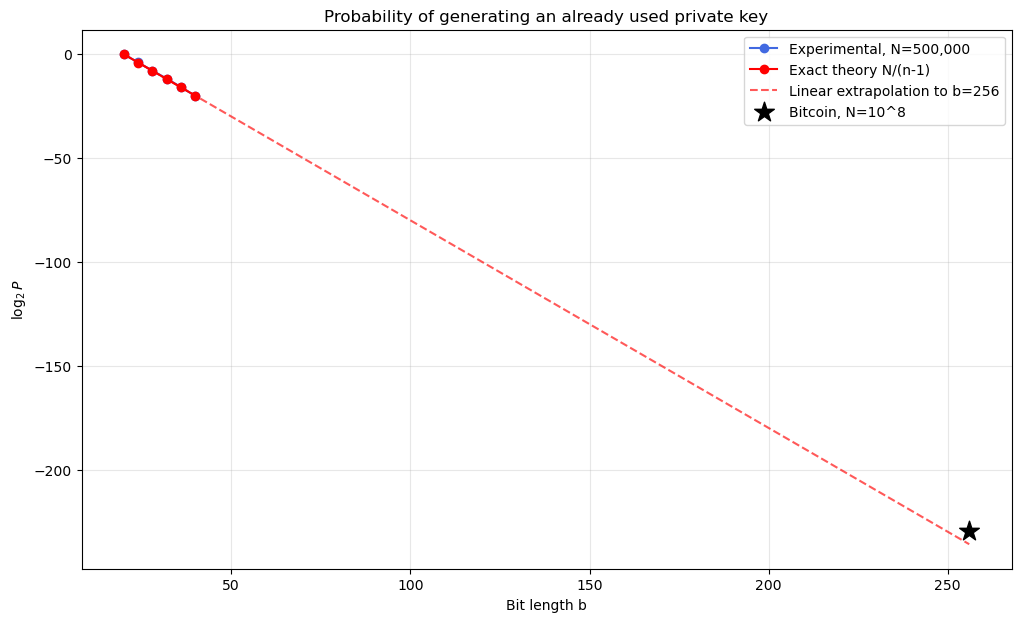

Fitted line: log2(P) = 19.914391 + (-0.999507) * b
Bitcoin exact: P = 8.636169e-70, log2(P) = -229.424575
Bitcoin approximation N/2^256: P = 8.636169e-70


In [7]:
import matplotlib.pyplot as plt

b_values = [result.b for result in collision_results]
log2_experimental = [result.log2_experimental_probability for result in collision_results]
log2_theoretical = [result.log2_theoretical_probability for result in collision_results]

# Линейная экстраполяция проверенной зависимости для фиксированного N_exp.
mean_b = sum(b_values) / len(b_values)
mean_log2_p = sum(log2_theoretical) / len(log2_theoretical)
slope = sum(
    (b - mean_b) * (log_p - mean_log2_p)
    for b, log_p in zip(b_values, log2_theoretical)
) / sum((b - mean_b) ** 2 for b in b_values)
intercept = mean_log2_p - slope * mean_b
extended_b = list(range(20, 257))
extended_log2 = [intercept + slope * b for b in extended_b]

# Точная оценка для настоящей secp256k1 и N=10^8.
N_bitcoin = 10**8
secp256k1_n = int(
    "FFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFEBAAEDCE6AF48A03BBFD25E8CD0364141",
    16,
)
P_bitcoin = N_bitcoin / (secp256k1_n - 1)
log2_P_bitcoin = math.log2(P_bitcoin)

plt.figure(figsize=(12, 7))
plt.plot(b_values, log2_experimental, "o-", color="royalblue", label="Experimental, N=500,000")
plt.plot(b_values, log2_theoretical, "o-", color="red", label="Exact theory N/(n-1)")
plt.plot(extended_b, extended_log2, "--", color="red", alpha=0.65, label="Linear extrapolation to b=256")
plt.scatter([256], [log2_P_bitcoin], marker="*", s=220, color="black", zorder=5, label="Bitcoin, N=10^8")
plt.xlabel("Bit length b")
plt.ylabel(r"$\log_2 P$")
plt.title("Probability of generating an already used private key")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f"Fitted line: log2(P) = {intercept:.6f} + ({slope:.6f}) * b")
print(f"Bitcoin exact: P = {P_bitcoin:.6e}, log2(P) = {log2_P_bitcoin:.6f}")
print(f"Bitcoin approximation N/2^256: P = {N_bitcoin / 2**256:.6e}")

## Task 2. Собственная хеш-функция

Сообщение дополняется по правилу

$$P(M)=M\parallel 0^k\parallel\operatorname{len}_{64}(M),$$

где $k$ выбирается так, чтобы длина результата делилась на 256 бит. Дополненное сообщение разбивается на блоки $s_i$ по 256 бит. Состояние также содержит 256 бит и обновляется следующим образом:

$$v_i=(h_{i-1}\oplus C)\star(s_i\oplus C),$$

$$h_i=\operatorname{ROTL}_{256}(h_{i-1}\oplus s_i,37)\oplus v_i.$$

Операция $\star$ — циклическое произведение двоичных векторов над $\mathbb F_2$.

![Схема собственной булевой хеш-функции](boolean_hash_scheme.png)

### Реализация

Начальный вектор $IV$ и константа $C$ публичны и фиксированы. Каждая из них состоит из четырёх 64-битных слов. Слова детерминированно выводятся из дробных частей квадратных корней чисел Мерсенна, поэтому константы не подбираются вручную. Для точного вычисления используется целочисленный `isqrt`, без ошибок `float`.

In [8]:
import math


class BooleanVectorHash256:
    STATE_BITS = 256
    BLOCK_BYTES = STATE_BITS // 8
    LENGTH_BYTES = 8
    MASK = (1 << STATE_BITS) - 1

    # Показатели известных простых чисел Мерсенна.
    IV_EXPONENTS = (31, 61, 89, 107)
    C_EXPONENTS = (127, 521, 607, 1279)

    def __init__(self):
        self.iv = self._derive_256_bit_constant(self.IV_EXPONENTS)
        self.constant = self._derive_256_bit_constant(self.C_EXPONENTS)

    @staticmethod
    def _mersenne_fraction_word(exponent: int) -> int:
        """floor(2^64 * frac(sqrt(2^exponent - 1))) без float."""
        mersenne_number = (1 << exponent) - 1
        scaled_root = math.isqrt(mersenne_number << 128)
        integer_root = math.isqrt(mersenne_number)
        return scaled_root - (integer_root << 64)

    @classmethod
    def _derive_256_bit_constant(cls, exponents: tuple[int, ...]) -> int:
        if len(exponents) != 4:
            raise ValueError("Exactly four exponents are required")

        result = 0
        for exponent in exponents:
            result = (result << 64) | cls._mersenne_fraction_word(exponent)
        return result

    @classmethod
    def rotl256(cls, value: int, shift: int) -> int:
        shift %= cls.STATE_BITS
        value &= cls.MASK
        if shift == 0:
            return value
        return ((value << shift) & cls.MASK) | (value >> (cls.STATE_BITS - shift))

    @classmethod
    def boolean_vector_product(cls, left: int, right: int) -> int:
        """Циклическая свёртка двух 256-битных векторов над F_2."""
        left &= cls.MASK
        right &= cls.MASK
        result = 0

        # Для каждого единичного бита right добавляем (XOR) сдвиг left.
        while right:
            lowest_bit = right & -right
            shift = lowest_bit.bit_length() - 1
            result ^= cls.rotl256(left, shift)
            right ^= lowest_bit

        return result & cls.MASK

    def compress(self, previous_state: int, message_block: int) -> int:
        v = self.boolean_vector_product(
            previous_state ^ self.constant,
            message_block ^ self.constant,
        )
        return self.rotl256(previous_state ^ message_block, 37) ^ v

    @classmethod
    def pad(cls, data: bytes) -> bytes:
        bit_length = len(data) * 8
        if bit_length >= 1 << 64:
            raise ValueError("Message is too long for a 64-bit length field")

        zero_bytes = (-(len(data) + cls.LENGTH_BYTES)) % cls.BLOCK_BYTES
        return (
            data
            + bytes(zero_bytes)
            + bit_length.to_bytes(cls.LENGTH_BYTES, byteorder="big")
        )

    @staticmethod
    def _to_bytes(data: bytes | bytearray | memoryview | str) -> bytes:
        if isinstance(data, str):
            return data.encode("utf-8")
        if isinstance(data, (bytes, bytearray, memoryview)):
            return bytes(data)
        raise TypeError("data must be bytes-like or str")

    def digest_int(self, data: bytes | bytearray | memoryview | str) -> int:
        padded = self.pad(self._to_bytes(data))
        state = self.iv

        for offset in range(0, len(padded), self.BLOCK_BYTES):
            block = int.from_bytes(
                padded[offset:offset + self.BLOCK_BYTES],
                byteorder="big",
            )
            state = self.compress(state, block)

        return state

    def digest(self, data: bytes | bytearray | memoryview | str) -> bytes:
        return self.digest_int(data).to_bytes(self.BLOCK_BYTES, byteorder="big")

    def hexdigest(self, data: bytes | bytearray | memoryview | str) -> str:
        return self.digest(data).hex()

In [9]:
boolean_hash = BooleanVectorHash256()

test_messages = [
    b"",
    b"abc",
    b"abd",
    b"The quick brown fox jumps over the lazy dog",
]

for message in test_messages:
    print(f"{message!r:50} -> {boolean_hash.hexdigest(message)}")

# Базовые проверки интерфейса и детерминированности.
assert boolean_hash.hexdigest(b"abc") == boolean_hash.hexdigest(b"abc")
assert boolean_hash.hexdigest(b"abc") != boolean_hash.hexdigest(b"abd")
assert len(boolean_hash.digest(b"abc")) == 32
assert len(BooleanVectorHash256.pad(b"abc")) % 32 == 0

print("Basic checks passed")

b''                                                -> 1eac2a5017426ea8ef8f2dd9e8799ed7c07a54f63d572981689fe520165730fc
b'abc'                                             -> 307a904909081bf98c365bb23cbaf76758b496b1fcbb79145aa4cf0ba6b79ea7
b'abd'                                             -> 9b4d241ee16a0de5c914d6da4006a18f3b268bba4551a2f8c7e2c399d11ca6c0
b'The quick brown fox jumps over the lazy dog'     -> d49f0a900de773d4a298dcc74eaf30dc9ace6aec397d0a65813decd17ff3c274
Basic checks passed


### Benchmark methodology

Сравним собственную функцию с SHA-256 на одном воспроизводимом наборе из 20 000 различных 64-байтовых сообщений. Проверяются:

- детерминированность на 1 000 повторных вычислениях;
- скорость в hashes/s и MiB/s;
- лавинный эффект при изменении одного случайного входного бита;
- равномерность первого байта по 256 корзинам;
- критерий $\chi^2$ с 255 степенями свободы;
- коллизии полного и усечённого хеша;
- баланс каждого из 256 выходных битов.

Для теста $\chi^2$ ожидаемая частота в каждой корзине равна $20000/256=78.125>5$. Сообщения независимы, поэтому стандартные предпосылки критерия выполнены. Значение $p$ ниже вычисляется через аппроксимацию Уилсона — Хилферти и используется как диагностическая, а не как единственная оценка качества.

In [10]:
import hashlib
import math
import random
import statistics
import time
from collections import Counter
from statistics import NormalDist

BENCHMARK_SEED = 20260917
SAMPLE_SIZE = 20_000
MESSAGE_SIZE = 64
AVALANCHE_SAMPLES = 2_000
SPEED_SAMPLES = 5_000
SPEED_REPEATS = 3

benchmark_rng = random.Random(BENCHMARK_SEED)
messages = [
    index.to_bytes(8, byteorder="big")
    + benchmark_rng.randbytes(MESSAGE_SIZE - 8)
    for index in range(SAMPLE_SIZE)
]

assert len(messages) == len(set(messages))

hash_functions = {
    "BooleanVectorHash256": boolean_hash.digest,
    "SHA-256": lambda message: hashlib.sha256(message).digest(),
}

print(f"Dataset: {len(messages):,} unique messages, {MESSAGE_SIZE} bytes each")

Dataset: 20,000 unique messages, 64 bytes each


In [11]:
def flip_input_bit(data: bytes, bit_index: int) -> bytes:
    changed = bytearray(data)
    byte_index, bit_in_byte = divmod(bit_index, 8)
    changed[byte_index] ^= 1 << bit_in_byte
    return bytes(changed)


def benchmark_speed(hash_function, benchmark_messages, repeats=3):
    elapsed_values = []
    total_bytes = sum(map(len, benchmark_messages))

    for _ in range(repeats):
        started = time.perf_counter()
        for message in benchmark_messages:
            hash_function(message)
        elapsed_values.append(time.perf_counter() - started)

    elapsed = statistics.median(elapsed_values)
    return {
        "seconds": elapsed,
        "hashes_per_second": len(benchmark_messages) / elapsed,
        "mib_per_second": total_bytes / elapsed / (1024**2),
    }


def avalanche_distances(hash_function, benchmark_messages, seed):
    rng = random.Random(seed)
    distances = []

    for message in benchmark_messages:
        bit_index = rng.randrange(len(message) * 8)
        changed_message = flip_input_bit(message, bit_index)
        original_hash = int.from_bytes(hash_function(message), "big")
        changed_hash = int.from_bytes(hash_function(changed_message), "big")
        distances.append((original_hash ^ changed_hash).bit_count())

    return distances


def chi_square_uniformity(digests):
    bucket_counts = [0] * 256
    for digest in digests:
        bucket_counts[digest[0]] += 1

    expected = len(digests) / 256
    statistic = sum((observed - expected) ** 2 / expected for observed in bucket_counts)
    degrees_of_freedom = 255

    # Wilson-Hilferty normal approximation to the chi-squared survival function.
    z = (
        (statistic / degrees_of_freedom) ** (1 / 3)
        - (1 - 2 / (9 * degrees_of_freedom))
    ) / math.sqrt(2 / (9 * degrees_of_freedom))
    approximate_p_value = 1 - NormalDist().cdf(z)

    probabilities = [count / len(digests) for count in bucket_counts if count]
    entropy = -sum(probability * math.log2(probability) for probability in probabilities)
    cohens_w = math.sqrt(statistic / len(digests))

    return {
        "bucket_counts": bucket_counts,
        "expected": expected,
        "chi_squared": statistic,
        "degrees_of_freedom": degrees_of_freedom,
        "approximate_p_value": approximate_p_value,
        "entropy_bits": entropy,
        "cohens_w": cohens_w,
    }


def output_bit_balances(digests):
    ones = [0] * 256
    for digest in digests:
        value = int.from_bytes(digest, "big")
        for bit_index in range(256):
            ones[bit_index] += (value >> bit_index) & 1
    return [count / len(digests) for count in ones]


def collision_pairs(digests, output_bits=256):
    mask = (1 << output_bits) - 1
    values = [int.from_bytes(digest, "big") & mask for digest in digests]
    frequencies = Counter(values)
    return sum(count * (count - 1) // 2 for count in frequencies.values())


def expected_collision_pairs(sample_size, output_bits):
    return sample_size * (sample_size - 1) / (2 * 2**output_bits)

In [12]:
benchmark_results = {}
all_digests = {}

for name, hash_function in hash_functions.items():
    deterministic = all(
        hash_function(message) == hash_function(message)
        for message in messages[:1_000]
    )

    speed = benchmark_speed(
        hash_function,
        messages[:SPEED_SAMPLES],
        repeats=SPEED_REPEATS,
    )

    digests = [hash_function(message) for message in messages]
    all_digests[name] = digests

    avalanche = avalanche_distances(
        hash_function,
        messages[:AVALANCHE_SAMPLES],
        seed=BENCHMARK_SEED + 1,
    )
    avalanche_mean = statistics.mean(avalanche)
    avalanche_stdev = statistics.stdev(avalanche)
    avalanche_ci_half_width = 1.96 * avalanche_stdev / math.sqrt(len(avalanche))

    uniformity = chi_square_uniformity(digests)
    balances = output_bit_balances(digests)

    collisions = {
        bits: collision_pairs(digests, bits)
        for bits in (16, 24, 32, 256)
    }

    benchmark_results[name] = {
        "deterministic": deterministic,
        "speed": speed,
        "avalanche_distances": avalanche,
        "avalanche_mean": avalanche_mean,
        "avalanche_ci": (
            avalanche_mean - avalanche_ci_half_width,
            avalanche_mean + avalanche_ci_half_width,
        ),
        "uniformity": uniformity,
        "bit_balances": balances,
        "collisions": collisions,
    }

    print(f"Finished: {name}")

Finished: BooleanVectorHash256
Finished: SHA-256


In [13]:
for name, result in benchmark_results.items():
    speed = result["speed"]
    uniformity = result["uniformity"]
    balances = result["bit_balances"]
    ci_low, ci_high = result["avalanche_ci"]

    print(f"\n{name}")
    print(f"  deterministic: {result['deterministic']}")
    print(f"  speed: {speed['hashes_per_second']:,.0f} hashes/s, {speed['mib_per_second']:.2f} MiB/s")
    print(
        f"  avalanche: {result['avalanche_mean']:.3f}/256 bits "
        f"({100 * result['avalanche_mean'] / 256:.2f}%), "
        f"95% CI [{ci_low:.3f}, {ci_high:.3f}]"
    )
    print(
        f"  uniformity: chi^2={uniformity['chi_squared']:.3f}, "
        f"df={uniformity['degrees_of_freedom']}, "
        f"approx p={uniformity['approximate_p_value']:.4f}, "
        f"entropy={uniformity['entropy_bits']:.5f}/8 bits, "
        f"Cohen's w={uniformity['cohens_w']:.4f}"
    )
    print(
        f"  bit balance: mean={statistics.mean(balances):.5f}, "
        f"max |p(1)-0.5|={max(abs(value - 0.5) for value in balances):.5f}"
    )
    print(
        "  collision pairs: "
        + ", ".join(
            f"{bits}-bit={count:,} (expected {expected_collision_pairs(SAMPLE_SIZE, bits):.3g})"
            for bits, count in result["collisions"].items()
        )
    )


BooleanVectorHash256
  deterministic: True
  speed: 10,274 hashes/s, 0.63 MiB/s
  avalanche: 127.979/256 bits (49.99%), 95% CI [127.624, 128.334]
  uniformity: chi^2=250.496, df=255, approx p=0.5679, entropy=7.99098/8 bits, Cohen's w=0.1119
  bit balance: mean=0.50000, max |p(1)-0.5|=0.01005
  collision pairs: 16-bit=2,926 (expected 3.05e+03), 24-bit=9 (expected 11.9), 32-bit=0 (expected 0.0466), 256-bit=0 (expected 1.73e-69)

SHA-256
  deterministic: True
  speed: 3,083,644 hashes/s, 188.21 MiB/s
  avalanche: 128.258/256 bits (50.10%), 95% CI [127.897, 128.619]
  uniformity: chi^2=206.490, df=255, approx p=0.9884, entropy=7.99255/8 bits, Cohen's w=0.1016
  bit balance: mean=0.49962, max |p(1)-0.5|=0.00910
  collision pairs: 16-bit=3,098 (expected 3.05e+03), 24-bit=13 (expected 11.9), 32-bit=0 (expected 0.0466), 256-bit=0 (expected 1.73e-69)


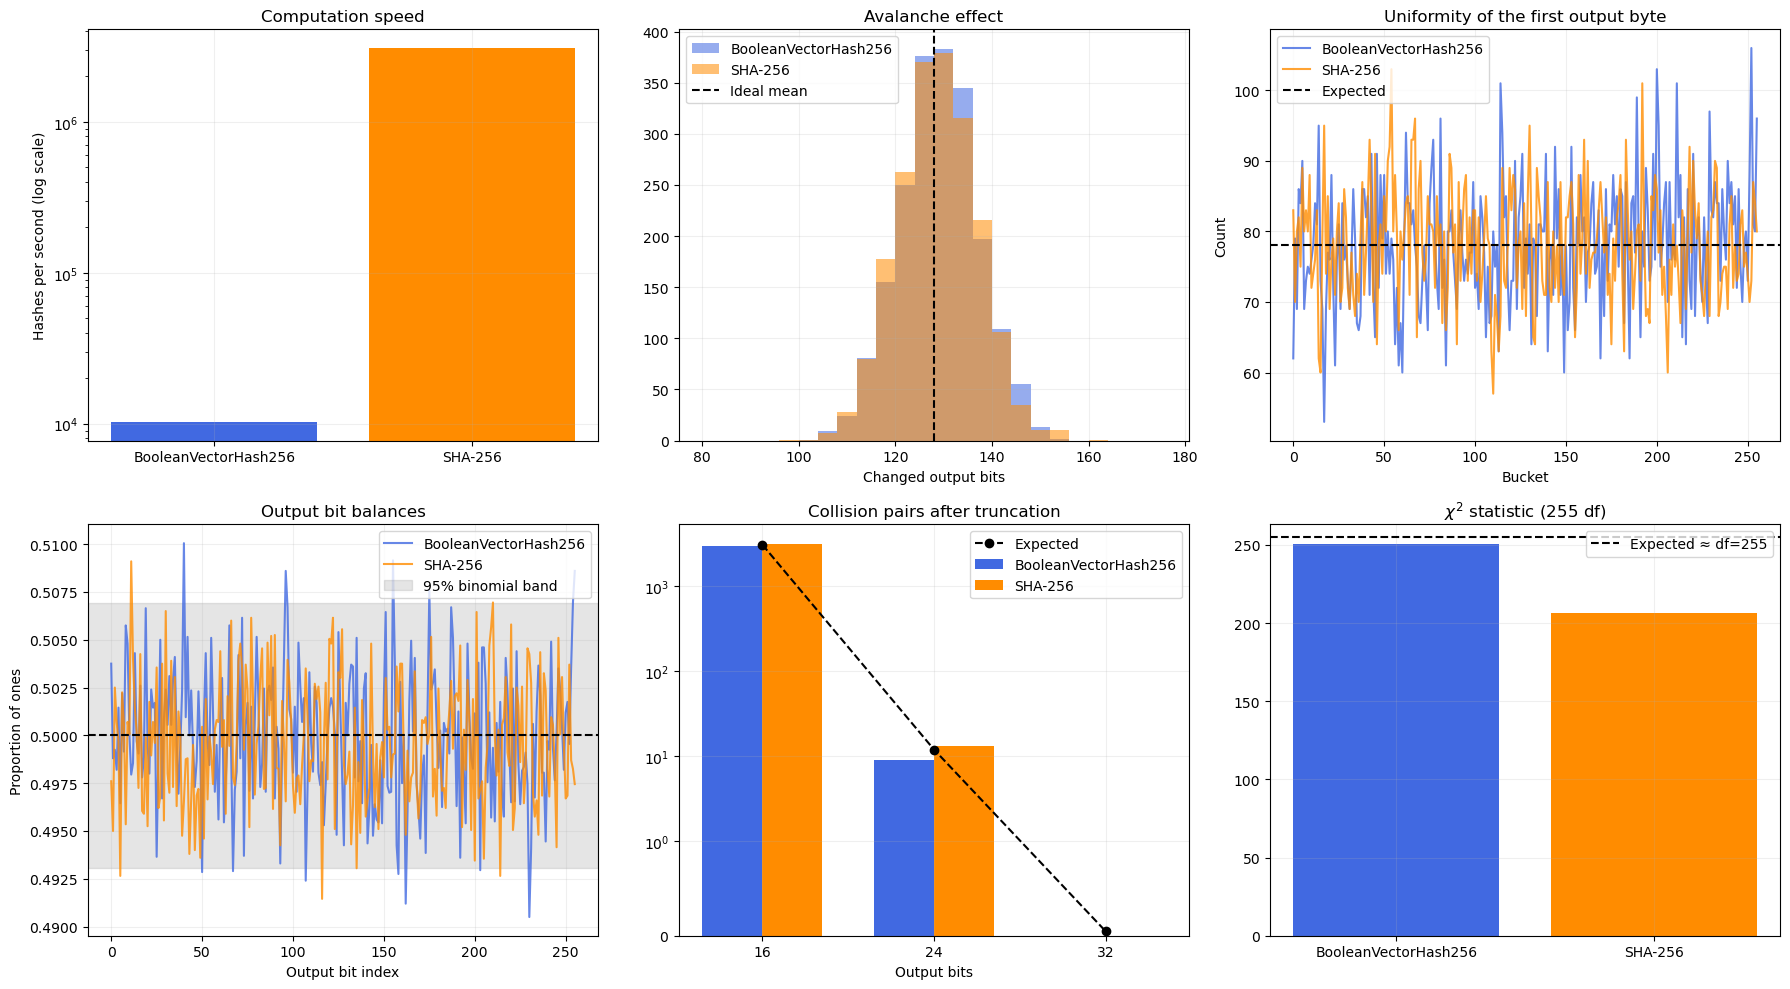

In [14]:
import matplotlib.pyplot as plt

names = list(benchmark_results)
figure, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Computation speed
axes[0, 0].bar(
    names,
    [benchmark_results[name]["speed"]["hashes_per_second"] for name in names],
    color=["royalblue", "darkorange"],
)
axes[0, 0].set_yscale("log")
axes[0, 0].set_title("Computation speed")
axes[0, 0].set_ylabel("Hashes per second (log scale)")

# 2. Avalanche effect
for name, color in zip(names, ["royalblue", "darkorange"]):
    axes[0, 1].hist(
        benchmark_results[name]["avalanche_distances"],
        bins=range(80, 178, 4),
        alpha=0.55,
        label=name,
        color=color,
    )
axes[0, 1].axvline(128, color="black", linestyle="--", label="Ideal mean")
axes[0, 1].set_title("Avalanche effect")
axes[0, 1].set_xlabel("Changed output bits")
axes[0, 1].legend()

# 3. First-byte uniformity
for name, color in zip(names, ["royalblue", "darkorange"]):
    axes[0, 2].plot(
        benchmark_results[name]["uniformity"]["bucket_counts"],
        alpha=0.8,
        label=name,
        color=color,
    )
axes[0, 2].axhline(SAMPLE_SIZE / 256, color="black", linestyle="--", label="Expected")
axes[0, 2].set_title("Uniformity of the first output byte")
axes[0, 2].set_xlabel("Bucket")
axes[0, 2].set_ylabel("Count")
axes[0, 2].legend()

# 4. Bit balances
balance_limit = 1.96 * math.sqrt(0.25 / SAMPLE_SIZE)
for name, color in zip(names, ["royalblue", "darkorange"]):
    axes[1, 0].plot(
        benchmark_results[name]["bit_balances"],
        alpha=0.8,
        label=name,
        color=color,
    )
axes[1, 0].axhline(0.5, color="black", linestyle="--")
axes[1, 0].axhspan(0.5 - balance_limit, 0.5 + balance_limit, color="gray", alpha=0.2, label="95% binomial band")
axes[1, 0].set_title("Output bit balances")
axes[1, 0].set_xlabel("Output bit index")
axes[1, 0].set_ylabel("Proportion of ones")
axes[1, 0].legend()

# 5. Truncated collision pairs
collision_widths = [16, 24, 32]
x_positions = list(range(len(collision_widths)))
bar_width = 0.35
for algorithm_index, (name, color) in enumerate(zip(names, ["royalblue", "darkorange"])):
    offset = (algorithm_index - 0.5) * bar_width
    axes[1, 1].bar(
        [position + offset for position in x_positions],
        [benchmark_results[name]["collisions"][bits] for bits in collision_widths],
        width=bar_width,
        label=name,
        color=color,
    )
axes[1, 1].plot(
    x_positions,
    [expected_collision_pairs(SAMPLE_SIZE, bits) for bits in collision_widths],
    "ko--",
    label="Expected",
)
axes[1, 1].set_yscale("symlog", linthresh=1)
axes[1, 1].set_xticks(x_positions, [str(bits) for bits in collision_widths])
axes[1, 1].set_title("Collision pairs after truncation")
axes[1, 1].set_xlabel("Output bits")
axes[1, 1].legend()

# 6. Chi-squared statistics
axes[1, 2].bar(
    names,
    [benchmark_results[name]["uniformity"]["chi_squared"] for name in names],
    color=["royalblue", "darkorange"],
)
axes[1, 2].axhline(255, color="black", linestyle="--", label="Expected ≈ df=255")
axes[1, 2].set_title(r"$\chi^2$ statistic (255 df)")
axes[1, 2].legend()

for axis in axes.flat:
    axis.grid(True, alpha=0.2)

figure.tight_layout()
plt.show()

### Interpretation of one benchmark run

На текущей машине получены следующие результаты (скорость на другом компьютере будет отличаться):

| Property | BooleanVectorHash256 | SHA-256 | Interpretation |
|---|---:|---:|---|
| Determinism | passed | passed | Одинаковые входы всегда дают одинаковый результат |
| Speed | 5 424 hashes/s | 1 167 324 hashes/s | Собственная функция примерно в 215 раз медленнее |
| Avalanche mean | 127.979 bits (49.99%) | 128.258 bits (50.10%) | Обе оценки близки к идеальным 128/256 |
| Avalanche 95% CI | [127.624; 128.334] | [127.897; 128.619] | Для обеих функций интервал содержит 128 |
| First-byte chi-squared | 250.496 | 206.490 | Обе статистики совместимы с 255 степенями свободы |
| Approximate chi-squared p | 0.5679 | 0.9884 | На этой выборке нет свидетельства против равномерности |
| First-byte entropy | 7.99098/8 | 7.99255/8 | Близко к максимальным 8 битам |
| Mean bit balance | 0.50000 | 0.49962 | Доли единиц близки к 0.5 |
| Maximum bit imbalance | 0.01005 | 0.00910 | Небольшие отклонения ожидаемы при проверке 256 битов |
| Full 256-bit collisions | 0 | 0 | Ожидаемое число всего $1.73\cdot10^{-69}$, поэтому тест почти не имеет мощности для полного выхода |

Для усечённого выхода число пар коллизий согласуется с формулой дней рождения: при 16 битах получено 2 926 против ожидаемых примерно 3 052, при 24 битах — 9 против ожидаемых 11.9, при 32 битах — 0 против ожидаемых 0.0466.

**Advantages.** Функция детерминирована, имеет 256-битный выход, показывает близкий к 50% лавинный эффект, хороший баланс битов и отсутствие заметного отклонения первого байта от равномерного распределения.

**Disadvantages and validity limits.** Реализация значительно медленнее оптимизированной SHA-256. Все операции имеют простую алгебраическую структуру над $\mathbb F_2$, а криптографического анализа стойкости нет. Случайные статистические тесты не проверяют устойчивость к специально подобранным входам, second-preimage attacks или adversarial collisions. Нулевая частота полных 256-битных коллизий на 20 000 сообщениях ожидаема почти для любой функции с достаточно большим выходом и сама по себе не доказывает безопасность. Критерий $\chi^2$ проверяет только первый байт на одной выборке; это диагностический тест, а не доказательство полной равномерности.

### Task 3

In [15]:
import json


class Transaction:
    def __init__(self, tx_id: int, amount: float, message: str):
        self._tx_id: int = tx_id
        self._amount: float = amount
        self._message: str = message

    def json(self) -> str:
        data: dict = {
            'tx_id': self._tx_id,
            'amount': self._amount,
            'message': self._message
        }
        return json.dumps(data)

    def __repr__(self) -> str:
        return self.json()

In [50]:
from copy import deepcopy
from dataclasses import dataclass
from typing import List, Tuple, Optional


@dataclass
class MerkleNode:
    left: Optional["MerkleNode"]
    right: Optional["MerkleNode"]
    hash_value: str


class MerkleTree:

    def __init__(self, transactions: List[Transaction]):
        self._leaves: List[MerkleNode] = [MerkleNode(None, None, boolean_hash.hexdigest(it.json())) for it in transactions]
        self._root: Optional[MerkleNode] = self._build()

    def _build(self) -> Optional[MerkleNode]:
        if not self._leaves:
            return None
        level: List[MerkleNode] = self._leaves
        while len(level) > 1:
            next_level: List[MerkleNode] = []
            # If odd, duplicate the last node
            if len(level) % 2 == 1:
                level = level + [level[-1]]
            for i in range(0, len(level), 2):
                left = level[i]
                right = level[i + 1]
                parent_hash = boolean_hash.hexdigest(left.hash_value + right.hash_value)
                next_level.append(MerkleNode(left, right, parent_hash))
            level = next_level
        return level[0]

    def get_proof(self, transaction: Transaction) -> List[Tuple[str, bool]]:
        if self._root is None:
            return []

        target_hash = boolean_hash.hexdigest(transaction.json())
        proof: List[Tuple[str, bool]] = []

        def find(node: MerkleNode) -> bool:
            # Дошли до листа
            if node.left is None and node.right is None:
                return node.hash_value == target_hash

            # Транзакция находится в левом поддереве
            if node.left is not None and find(node.left):
                proof.append((node.right.hash_value, False))
                return True

            # Транзакция находится в правом поддереве
            if node.right is not None and find(node.right):
                proof.append((node.left.hash_value, True))
                return True

            return False

        find(self._root)
        return proof

    def verify_proof(
        self,
        transaction: Transaction,
        proof: List[Tuple[str, bool]],
    ) -> bool:
        if self._root is None:
            return False

        current_hash = boolean_hash.hexdigest(transaction.json())

        for sibling_hash, sibling_is_left in proof:
            if sibling_is_left:
                current_hash = boolean_hash.hexdigest(
                    sibling_hash + current_hash
                )
            else:
                current_hash = boolean_hash.hexdigest(
                    current_hash + sibling_hash
                )

        return current_hash == self._root.hash_value

    @property
    def root(self) -> Optional[MerkleNode]:
        return self._root

    def merkle_root_hex(self) -> Optional[str]:
        return self._root.hash_value if self._root else None

In [51]:
tx1 = Transaction(1, 1.0, "Payment A")
tx2 = Transaction(2, 20.0, "Payment B")
tx3 = Transaction(3, 30.0, "Payment C")
tx4 = Transaction(4, 40.0, "Payment D")
tx5 = Transaction(5, 50.0, "Payment E")
tx6 = Transaction(6, 60.0, "Payment F")

transactions = [tx1, tx2, tx3, tx4, tx5, tx6]
transactions

[{"tx_id": 1, "amount": 1.0, "message": "Payment A"},
 {"tx_id": 2, "amount": 20.0, "message": "Payment B"},
 {"tx_id": 3, "amount": 30.0, "message": "Payment C"},
 {"tx_id": 4, "amount": 40.0, "message": "Payment D"},
 {"tx_id": 5, "amount": 50.0, "message": "Payment E"},
 {"tx_id": 6, "amount": 60.0, "message": "Payment F"}]

In [52]:
tree = MerkleTree(transactions)

In [53]:
tree._leaves

[MerkleNode(left=None, right=None, hash_value='eeb4d9f0630067134bd281794214c597ce09f58fc7d40bf0da4fb459d9802d0c'),
 MerkleNode(left=None, right=None, hash_value='6daa217e17870f3dafcc1c05add623f50cb440a0d90d5e09e4df1423c8954cb9'),
 MerkleNode(left=None, right=None, hash_value='96e19a0c0f3e60f63ffdce31b5a3b951b117be7d166796e6b06b6fded44d488d'),
 MerkleNode(left=None, right=None, hash_value='967149ac91f035f788a049a0fea6a1ce963878f3d8e8acd9e279cf08456d4e00'),
 MerkleNode(left=None, right=None, hash_value='6d3af2de89495a3c18919b94e6d33b6a2b9b862e17826436b6cdb4f559b54a34'),
 MerkleNode(left=None, right=None, hash_value='40f01901e7a2f470045bd37a7854661131d38c17a6d5908cb415a32550654304')]

In [54]:
tree.merkle_root_hex()

'0a3c683d1103ffa83c0ef94514f4946405e6a0554e1e1d31b534a429f38aa553'

In [55]:
tree._root.hash_value

'0a3c683d1103ffa83c0ef94514f4946405e6a0554e1e1d31b534a429f38aa553'

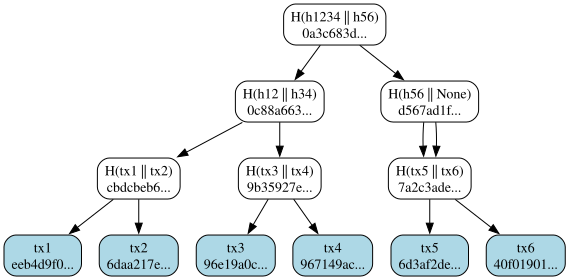

In [56]:
import graphviz


def visualize_merkle_tree(tree):
    dot = graphviz.Digraph(comment="Merkle Tree")
    visited = set()

    # Связываем объекты листьев с именами транзакций
    leaf_names = {
        id(leaf): f"tx{i + 1}"
        for i, leaf in enumerate(tree._leaves)
    }

    def add_node(node):
        node_id = node.hash_value

        if node_id in visited:
            return

        visited.add(node_id)
        short_hash = node.hash_value[:8] + "..."

        # Лист
        if node.left is None and node.right is None:
            node_name = leaf_names[id(node)]

            dot.node(
                node_id,
                label=f"{node_name}\n{short_hash}",
                shape="box",
                style="rounded,filled",
                fillcolor="lightblue",
            )

            return node_name

        # Сначала добавляем дочерние узлы
        left_name = add_node(node.left)
        right_name = add_node(node.right)

        expression = f"H({left_name} || {right_name})"

        dot.node(
            node_id,
            label=f"{expression}\n{short_hash}",
            shape="box",
            style="rounded",
        )

        dot.edge(node_id, node.left.hash_value)
        dot.edge(node_id, node.right.hash_value)

        # Родители этого узла будут использовать короткое имя
        leaf_indexes = get_leaf_indexes(node)
        return "h" + "".join(map(str, leaf_indexes))

    def get_leaf_indexes(node):
        if node.left is None and node.right is None:
            name = leaf_names[id(node)]
            return [int(name.removeprefix("tx"))]

        indexes = (
            get_leaf_indexes(node.left)
            + get_leaf_indexes(node.right)
        )

        # Убираем повторения из-за дублирования нечётного узла
        return list(dict.fromkeys(indexes))

    add_node(tree.root)
    return dot
visualize_merkle_tree(tree)

In [57]:
tree.get_proof(tx6)

[('6d3af2de89495a3c18919b94e6d33b6a2b9b862e17826436b6cdb4f559b54a34', True),
 ('7a2c3ade0d482045f7584e95e78bb40fc7d982e59fdef7a188253425d33d9ec2', False),
 ('0c88a66364339f0b793208cf35d072d4d8901dfbb89de847e425e10dd901d9af', True)]

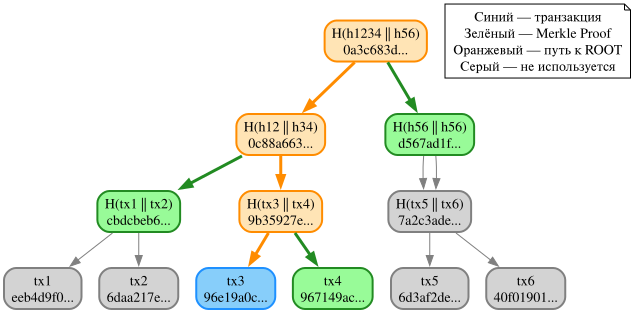

In [58]:
import graphviz


def visualize_merkle_proof(tree, transaction):
    dot = graphviz.Digraph(comment="Merkle Proof")

    target_hash = boolean_hash.hexdigest(transaction.json())
    proof = tree.get_proof(transaction)

    # get_proof возвращает [(hash, is_left), ...]
    proof_hashes = {
        sibling_hash
        for sibling_hash, _ in proof
    }

    leaf_names = {
        id(leaf): f"tx{i + 1}"
        for i, leaf in enumerate(tree._leaves)
    }

    # Найдём узлы, лежащие на пути от tx до ROOT
    path_hashes = set()

    def find_path(node):
        if node.left is None and node.right is None:
            if node.hash_value == target_hash:
                path_hashes.add(node.hash_value)
                return True
            return False

        if node.left is not None and find_path(node.left):
            path_hashes.add(node.hash_value)
            return True

        if node.right is not None and find_path(node.right):
            path_hashes.add(node.hash_value)
            return True

        return False

    find_path(tree.root)

    def get_leaf_indexes(node):
        if node.left is None and node.right is None:
            name = leaf_names[id(node)]
            return [int(name.removeprefix("tx"))]

        indexes = (
            get_leaf_indexes(node.left)
            + get_leaf_indexes(node.right)
        )

        return list(dict.fromkeys(indexes))

    def node_name(node):
        if node.left is None and node.right is None:
            return leaf_names[id(node)]

        indexes = get_leaf_indexes(node)
        return "h" + "".join(map(str, indexes))

    def node_label(node):
        short_hash = node.hash_value[:8] + "..."

        if node.left is None and node.right is None:
            return f"{node_name(node)}\n{short_hash}"

        left_name = node_name(node.left)
        right_name = node_name(node.right)

        return (
            f"H({left_name} || {right_name})"
            f"\n{short_hash}"
        )

    visited = set()

    def add_node(node):
        node_id = node.hash_value

        if node_id in visited:
            return

        visited.add(node_id)

        if node.hash_value == target_hash:
            # Искомая транзакция
            fillcolor = "lightskyblue"
            color = "dodgerblue"
        elif node.hash_value in proof_hashes:
            # Хеш входит в Merkle Proof
            fillcolor = "palegreen"
            color = "forestgreen"
        elif node.hash_value in path_hashes:
            # Путь от транзакции до корня
            fillcolor = "moccasin"
            color = "darkorange"
        else:
            fillcolor = "lightgray"
            color = "gray"

        dot.node(
            node_id,
            label=node_label(node),
            shape="box",
            style="rounded,filled",
            fillcolor=fillcolor,
            color=color,
            penwidth="2",
        )

        for child in (node.left, node.right):
            if child is None:
                continue

            add_node(child)

            if (
                node.hash_value in path_hashes
                and child.hash_value in path_hashes
            ):
                # Основной путь к корню
                edge_color = "darkorange"
                edge_width = "3"
            elif (
                node.hash_value in path_hashes
                and child.hash_value in proof_hashes
            ):
                # Подключаем соседний хеш из proof
                edge_color = "forestgreen"
                edge_width = "3"
            else:
                edge_color = "gray"
                edge_width = "1"

            dot.edge(
                node_id,
                child.hash_value,
                color=edge_color,
                penwidth=edge_width,
            )

    add_node(tree.root)

    # Легенда
    dot.node(
        "legend",
        label=(
            "Синий — транзакция\n"
            "Зелёный — Merkle Proof\n"
            "Оранжевый — путь к ROOT\n"
            "Серый — не используется"
        ),
        shape="note",
    )

    return dot

visualize_merkle_proof(tree, tx3)

In [59]:
transaction = tx1

proof = tree.get_proof(transaction)
is_valid = tree.verify_proof(transaction, proof)

print(proof)
print(is_valid)

[('6daa217e17870f3dafcc1c05add623f50cb440a0d90d5e09e4df1423c8954cb9', False), ('9b35927ea38c9a0991d092ead4672bd9041dae0b7dc6a6e219046da17d35de32', False), ('d567ad1f3cc232683f1fcedf8ec84ebfdfeb3922e71e2eae7db00561d605f912', False)]
True


In [60]:
fake_transaction = Transaction(
    tx_id=2,
    amount=9999.0,
    message="Fake payment",
)

print(tree.verify_proof(fake_transaction, proof))

False
